In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
def jacobi(A, b, x0, tol, max_iterations):
    errors = []
    timestart = time.time()
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)
        
        # Check for convergence
        if err < tol:
            timeend = time.time()
            timediff = timeend - timestart
            return x_new, k, timediff, errors
        x = x_new
    timeend = time.time()
    timediff = timeend - timestart
    return x, max_iterations, timediff, errors



In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

def gauss_seidel(A, b, x0, tol, max_iterations):
    errors = []
    n = len(b)
    x = x0.copy()
    timestart = time.time()

    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)
        # Check for convergence
        if err < tol:
            timeend = time.time()
            timediff = timeend - timestart
            return x_new, k, timediff, errors
        x = x_new
    timeend = time.time()
    timediff = timeend - timestart
    return x, max_iterations, timediff, errors

Tolerance: 0.001
The number of Jacobi iterations: 4
The number of Gauss-Seidel iterations: 4



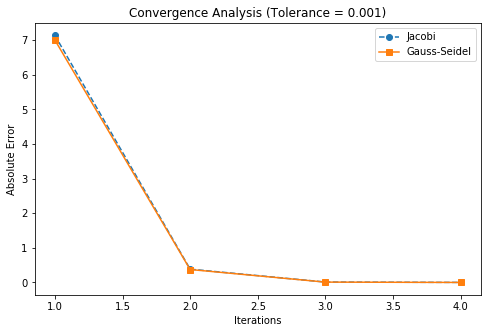

Tolerance: 1e-06
The number of Jacobi iterations: 7
The number of Gauss-Seidel iterations: 5



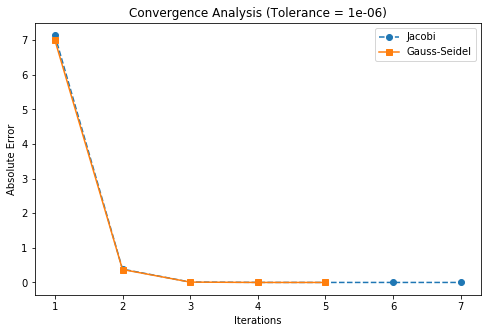

Tolerance: 1e-09
The number of Jacobi iterations: 9
The number of Gauss-Seidel iterations: 7



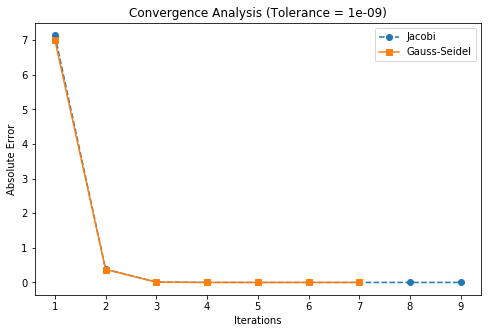

In [3]:
A = np.array([
    [3.0, -0.1, -0.2],
    [0.1,  7.0, -0.3],
    [0.3, -0.2, 10.0]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)
x0_1 = np.array([0.0, 0.0, 0.0])
tolerances = [1e-3, 1e-6, 1e-9]
max_iterations = 100
for tol in tolerances:
    solution1, iterations1, timediff1, errors1 = jacobi(A, b, x0_1, tol, max_iterations)
    solution2, iterations2, timediff2, errors2 = gauss_seidel(A, b, x0_1, tol, max_iterations)
    print(f"Tolerance: {tol}")
    print(f"The number of Jacobi iterations: {iterations1+1}")
    print(f"The number of Gauss-Seidel iterations: {iterations2+1}\n")
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(errors1) + 1), errors1, label='Jacobi', marker='o', linestyle='--')
    plt.plot(range(1, len(errors2) + 1), errors2, label='Gauss-Seidel', marker='s')

    plt.xlabel("Iterations")
    plt.ylabel("Absolute Error")
    plt.title(f"Convergence Analysis (Tolerance = {tol})")
    plt.legend()
    plt.show()
    


In [4]:
# The smaller the tolerance number, the more iterations that are needed since the error values need to become
# increasingly smaller. So that is why for the iteration where we did tol = 1e-9, it went up to 9/7 iterations
# vs the smaller iteration values of 4/4 for the tol = 1e-3.